In [4]:
import sys, random, numpy as np
sys.path.insert(0, r"C:\Users\Admin\Documents\GitHub\LPPLS_Boulder\src")  # not ../
random.seed(42)
np.random.seed(42)

from lppls import lppls_lm, data_loader

730189.9512174914 0.4338042272272775 4.830557704791259 8.655588316730945 -0.07082713976858034 -0.0029469324640137894 -0.0013204325891150329 0.0026345528510662583 5.975682987525428 2.158370646795736


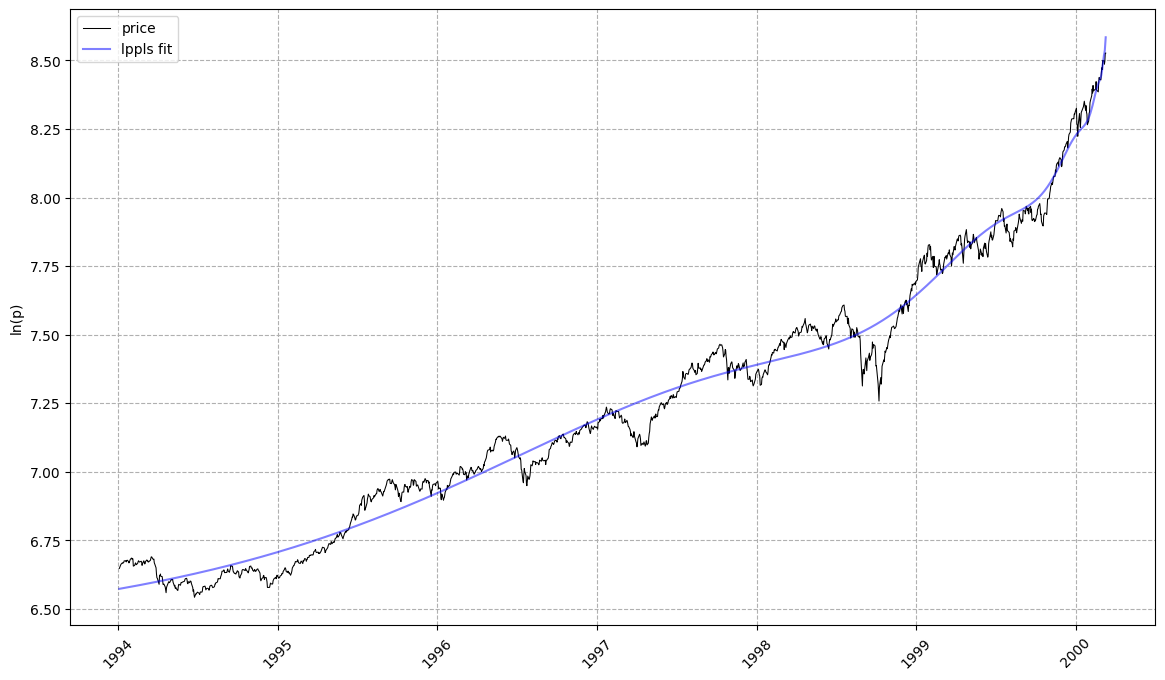

In [5]:
#from lppls import lppls_lm, data_loader
import numpy as np
import pandas as pd
from datetime import datetime as dt

%matplotlib inline

# read example dataset into df
data = data_loader.nasdaq_dotcom()

# Original
#time = [pd.Timestamp.toordinal(dt.strptime(t1, "%Y-%m-%d")) for t1 in data["Date"]]

#time = [dt.strptime(t1, "%Y-%m-%d").toordinal() for t1 in data["Date"]]
#time = pd.to_datetime(data["Date"]).map(lambda t: t.toordinal()).to_list()
time = pd.to_datetime(data["Date"]).map(lambda t: t.toordinal()).to_list()

price = np.log(data["Adj Close"].values)
observations = np.array([time, price])

# the literature suggests 25
MAX_SEARCHES = 25
lppls_model = lppls_lm.LPPLS_LM(observations=observations)

# fit the model to the data and get back the params
tc, m, w, a, b, c, c1, c2, O, D = lppls_model.fit(MAX_SEARCHES)
print(tc, m, w, a, b, c, c1, c2, O, D)

# visualize the fit
lppls_model.plot_fit()

Best seed: 133
Best SSE: 6.490878804094072
Params: (np.float64(730742.3933386002), np.float64(0.0606988156682885), np.float64(15.309459891704428), 24.46994445512896, -11.03316540395552, np.float64(-0.045393095336998895), -0.04292704957836585, -0.014758100107073093, np.float64(3.960329260270169), np.float64(0.9636751916753155))


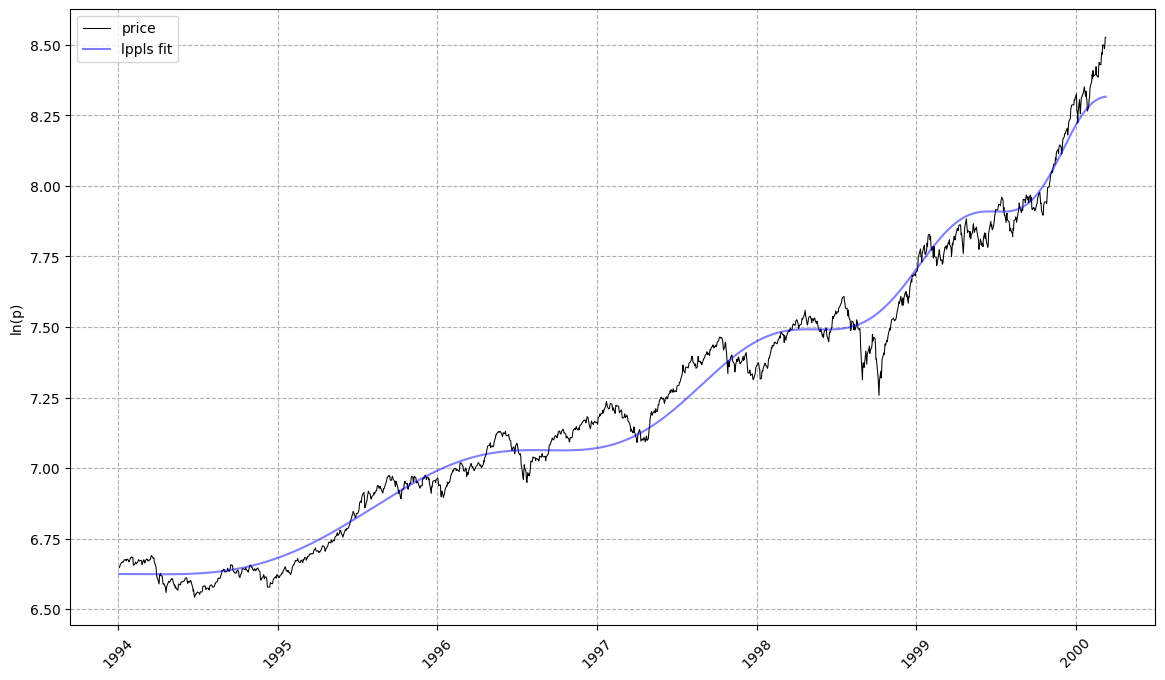

In [ ]:
import random
import numpy as np
import pandas as pd
from datetime import datetime as dt
from lppls import lppls_lm, data_loader  # use lppls_lm instead if you want LM variant

# Data
data = data_loader.nasdaq_dotcom()
time = np.array([dt.strptime(t, "%Y-%m-%d").toordinal() for t in data["Date"]])
price = np.log(data["Adj Close"].values)
observations = np.array([time, price])

MAX_SEARCHES = 25
SEED_GRID = range(300)  # increase for better chance of matching target curve

best = None  # (sse, seed, model, params)

for seed in SEED_GRID:
    random.seed(seed)
    np.random.seed(seed)

    model = lppls_lm.LPPLS_LM(observations=observations)
    tc, m, w, a, b, c, c1, c2, O, D = model.fit(MAX_SEARCHES)

    yhat = np.array([model.lppls(ti, tc, m, w, a, b, c1, c2) for ti in time])
    sse = float(np.sum((yhat - price) ** 2))

    if (best is None) or (sse < best[0]):
        best = (sse, seed, model, (tc, m, w, a, b, c, c1, c2, O, D))

best_sse, best_seed, best_model, best_params = best
print("Best seed:", best_seed) # Best seed: 133
print("Best SSE:", best_sse)
print("Params:", best_params)

# Repro check (same seed -> same result)
random.seed(best_seed)
np.random.seed(best_seed)

best_model.plot_fit()


100%|██████████| 1444/1444 [05:24<00:00,  4.45it/s]


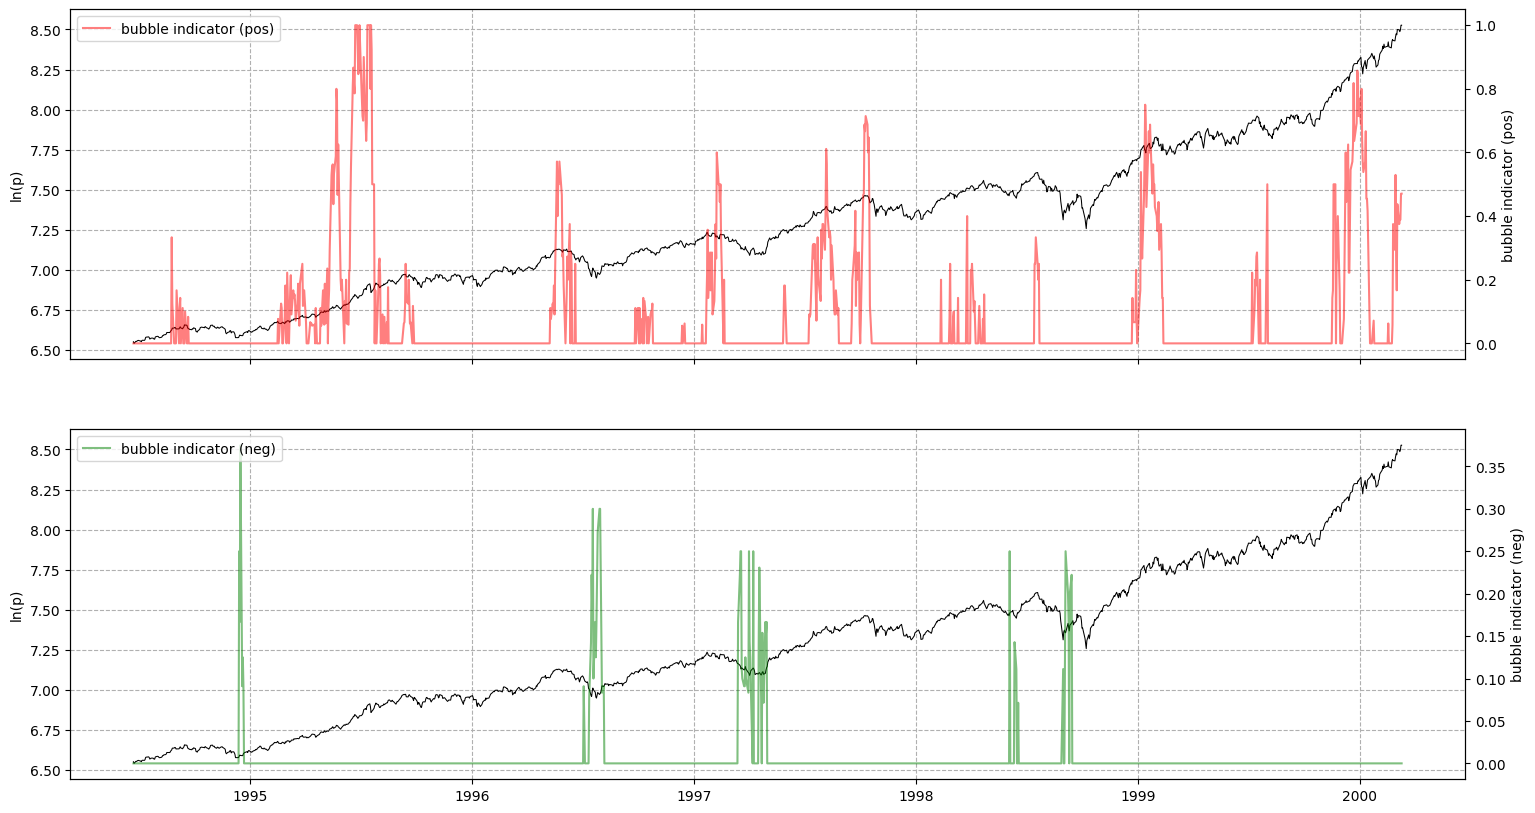

In [ ]:
# compute the confidence indicator
res = lppls_model.mp_compute_nested_fits(
    workers=8,
    window_size=120, 
    smallest_window_size=30, 
    outer_increment=1, 
    inner_increment=5, 
    max_searches=25,
    # filter_conditions_config={} # not implemented in 0.6.x
)

lppls_model.plot_confidence_indicators(res)
# duration of last run: [05:24<00:00,  4.45it/s]